# Repository Recommender - Data Exploration & Baseline Model

This notebook demonstrates the DS workflow for the git-query recommender:
1. Load repository dataset from the gateway API
2. Explore data distributions
3. Extract features for ranking
4. Train a baseline ranking model
5. Evaluate with IR metrics

In [1]:
import sys
sys.path.insert(0, '../../..')  # Add project root to path

import os
from dotenv import load_dotenv
load_dotenv(dotenv_path='../../../.env')  # Load .env from project root

from src.recommender.data import RepoDataset, FeatureExtractor
import pandas as pd
import numpy as np
import fastparquet
import pyarrow
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import ndcg_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import joblib
import os

RANDOM_STATE = 42

In [10]:
df = None

REPO_ROOT = Path.cwd().parents[3]
NOTEBOOK_DATA_DIR = Path.cwd() / "data"
REPO_DATA_DIR = REPO_ROOT / "data"

print("CWD:", Path.cwd())
print("REPO_ROOT:", REPO_ROOT)
print("NOTEBOOK_DATA_DIR exists?", NOTEBOOK_DATA_DIR.exists())
print("REPO_DATA_DIR exists?", REPO_DATA_DIR.exists())

# 1) Prefer the engineered CSV if present (this matches what you actually have)
csv_candidates = [
    NOTEBOOK_DATA_DIR / "features_engineered.csv",
    REPO_DATA_DIR / "features_engineered.csv",
]
csv_path = next((p for p in csv_candidates if p.exists()), None)

if csv_path is not None:
    print("Loading engineered CSV:", csv_path)
    df = pd.read_csv(csv_path)

# 2) Else try RepoDataset local cache (json/parquet)
if df is None:
    try:
        from src.recommender.data import RepoDataset

        local_candidates = [
            REPO_DATA_DIR / "repos.parquet",
            REPO_DATA_DIR / "repos.json",
            NOTEBOOK_DATA_DIR / "repos.parquet",
            NOTEBOOK_DATA_DIR / "repos.json",
        ]
        local_path = next((p for p in local_candidates if p.exists()), None)

        if local_path is not None:
            print("Loading via RepoDataset.from_local:", local_path)
            ds = RepoDataset.from_local(str(local_path))
            df = ds.to_dataframe()
    except Exception as e:
        print("Local RepoDataset load not used:", e)

# 3) Else try gateway if configured
if df is None:
    try:
        from src.recommender.data import RepoDataset

        GATEWAY_URL = os.getenv("GITQUERY_GATEWAY_URL") or os.getenv("GATEWAY_URL")
        API_KEY = os.getenv("GITQUERY_API_KEY") or os.getenv("API_KEY")

        if GATEWAY_URL and API_KEY:
            print("Fetching from gateway...")
            ds = RepoDataset.from_gateway(url=GATEWAY_URL, api_key=API_KEY, max_repos=5000)
            df = ds.to_dataframe()
        else:
            print("Gateway env vars not set (GITQUERY_GATEWAY_URL/GITQUERY_API_KEY).")
    except Exception as e:
        print("Gateway RepoDataset fetch not used:", e)

# Final
if df is None or len(df) == 0:
    print("Skipping EDA: df not loaded (no CSV found and no json/parquet/gateway available).")
else:
    print("Loaded df:", df.shape)
    display(df.head(5))

CWD: c:\Users\irina\OneDrive\Documentos\COMPUTER_SCIENCE_AND_AI_3\SECOND_SEMESTER\CHATBOTS\git-query\src\recommender\notebooks
REPO_ROOT: c:\Users\irina\OneDrive\Documentos\COMPUTER_SCIENCE_AND_AI_3\SECOND_SEMESTER\CHATBOTS
NOTEBOOK_DATA_DIR exists? True
REPO_DATA_DIR exists? False
Loading engineered CSV: c:\Users\irina\OneDrive\Documentos\COMPUTER_SCIENCE_AND_AI_3\SECOND_SEMESTER\CHATBOTS\git-query\src\recommender\notebooks\data\features_engineered.csv
Loaded df: (1000, 22)


,stars,forks,watchers,contributors,days_since_push,has_readme,readme_word_count,readme_char_count,topics_count,language,...,readme_svd_1,readme_svd_2,readme_svd_3,readme_svd_4,readme_svd_5,readme_svd_6,readme_svd_7,readme_svd_8,readme_svd_9,readme_top_term
0,426893,41377,8588,0,171.35,0,0,0,10,TypeScript,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,415801,38976,6247,0,173.74,0,0,0,6,Markdown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,396445,31414,8011,0,214.97,0,0,0,5,missing,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,366964,64025,9879,0,176.87,0,0,0,5,Python,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,363505,38166,4360,0,274.08,0,0,0,10,Python,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [11]:
def _col_exists(c): 
    return c in df.columns

def eda_overview(df):
    print("Shape:", df.shape)
    display(df.head(3))

    schema = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    }).sort_values(["missing_%", "n_unique"], ascending=False)

    display(schema.head(40))
    return schema

In [12]:
def eda_missingness(df, top_k=25):
    miss = df.isna().mean().sort_values(ascending=False).head(top_k)
    plt.figure(figsize=(10,4))
    miss.plot(kind="bar")
    plt.title(f"Missingness rate (top {top_k})")
    plt.ylabel("fraction missing")
    plt.tight_layout()
    plt.show()

In [13]:
def eda_duplicates(df):
    keys = [c for c in ["id", "full_name", "name", "html_url", "clone_url"] if c in df.columns]
    if not keys:
        print("No standard id/url/name keys found for duplicate check.")
        return
    for k in keys:
        print(f"Duplicates by {k}: {int(df[k].duplicated().sum())}")

In [14]:
def eda_numeric(df, max_cols=20):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        print("No numeric columns.")
        return
    display(num.describe(percentiles=[.5,.75,.9,.95,.99]).T.head(max_cols))

    # quick hist for a few likely columns if present
    likely = [c for c in ["stars","forks","watchers","open_issues","contributors","topics_count",
                          "readme_word_count","days_since_push"] if c in num.columns]
    for c in likely[:6]:
        plt.figure(figsize=(8,3))
        num[c].replace([np.inf, -np.inf], np.nan).dropna().clip(lower=0).hist(bins=50)
        plt.title(f"{c} distribution")
        plt.tight_layout()
        plt.show()

In [16]:
def eda_categorical(df, cols=None, top_k=20):
    if cols is None:
        cols = [c for c in ["language","license"] if c in df.columns]
    for c in cols:
        vc = df[c].fillna("missing").astype(str).value_counts().head(top_k)
        plt.figure(figsize=(10,4))
        vc.plot(kind="bar")
        plt.title(f"Top {top_k}: {c}")
        plt.tight_layout()
        plt.show()
        display(vc.to_frame("count"))

In [17]:
def eda_correlation(df, max_cols=12):
    num = df.select_dtypes(include=[np.number]).copy()
    if num.shape[1] < 2:
        print("Not enough numeric columns for correlation.")
        return
    # keep only columns with variance
    keep = [c for c in num.columns if num[c].nunique(dropna=True) > 1]
    num = num[keep]
    if num.shape[1] < 2:
        print("Not enough non-constant numeric columns for correlation.")
        return
    # limit
    cols = keep[:max_cols]
    corr = num[cols].corr()
    plt.figure(figsize=(8,6))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.colorbar()
    plt.title("Correlation (subset)")
    plt.tight_layout()
    plt.show()

In [18]:
def eda_text(df):
    # Works for either raw or engineered
    for c in ["readme", "description", "text"]:
        if c in df.columns:
            s = df[c].fillna("").astype(str)
            lengths = s.str.len()
            plt.figure(figsize=(8,3))
            lengths.clip(upper=lengths.quantile(0.99)).hist(bins=50)
            plt.title(f"{c} length (clipped p99)")
            plt.tight_layout()
            plt.show()
            print(f"{c}: empty rate =", float((s.str.strip() == "").mean()))

In [19]:
def eda_topic_like(df):
    # handles topics_list, topics_str, topics (list-as-string), etc.
    if "topics_list" in df.columns:
        lens = df["topics_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
        plt.figure(figsize=(8,3))
        lens.hist(bins=30)
        plt.title("topics_list length")
        plt.tight_layout()
        plt.show()
    elif "topics_str" in df.columns:
        lens = df["topics_str"].fillna("").astype(str).apply(lambda x: 0 if x.strip()=="" else len(x.split(",")))
        plt.figure(figsize=(8,3))
        lens.hist(bins=30)
        plt.title("topics_str count (comma-split)")
        plt.tight_layout()
        plt.show()
    elif "topics" in df.columns:
        # try to parse if it's a string representation
        s = df["topics"].fillna("")
        lens = s.apply(lambda x: len(x) if isinstance(x, list) else (len(str(x).split(",")) if str(x).strip() else 0))
        plt.figure(figsize=(8,3))
        lens.hist(bins=30)
        plt.title("topics count (best-effort)")
        plt.tight_layout()
        plt.show()

In [20]:
def eda_leakage_checks(df):
    # helpful because your CSV is "engineered"
    leak = [c for c in df.columns if any(k in c.lower() for k in ["query", "overlap", "relevance", "label", "target"])]
    print("Leakage/label-ish columns:", leak[:50])

    const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print("Constant columns:", const[:50])

    nan_top = df.isna().mean().sort_values(ascending=False).head(20)
    display(nan_top.to_frame("missing_fraction"))

Shape: (1000, 22)


,stars,forks,watchers,contributors,days_since_push,has_readme,readme_word_count,readme_char_count,topics_count,language,...,readme_svd_1,readme_svd_2,readme_svd_3,readme_svd_4,readme_svd_5,readme_svd_6,readme_svd_7,readme_svd_8,readme_svd_9,readme_top_term
0,426893,41377,8588,0,171.35,0,0,0,10,TypeScript,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,415801,38976,6247,0,173.74,0,0,0,6,Markdown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,396445,31414,8011,0,214.97,0,0,0,5,missing,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


,dtype,missing,missing_%,n_unique
readme_top_term,float64,1000,100.0,0
stars,int64,0,0.0,988
forks,int64,0,0.0,958
watchers,int64,0,0.0,749
days_since_push,float64,0,0.0,725
language,object,0,0.0,44
license,object,0,0.0,20
topics_count,int64,0,0.0,11
contributors,int64,0,0.0,1
has_readme,int64,0,0.0,1


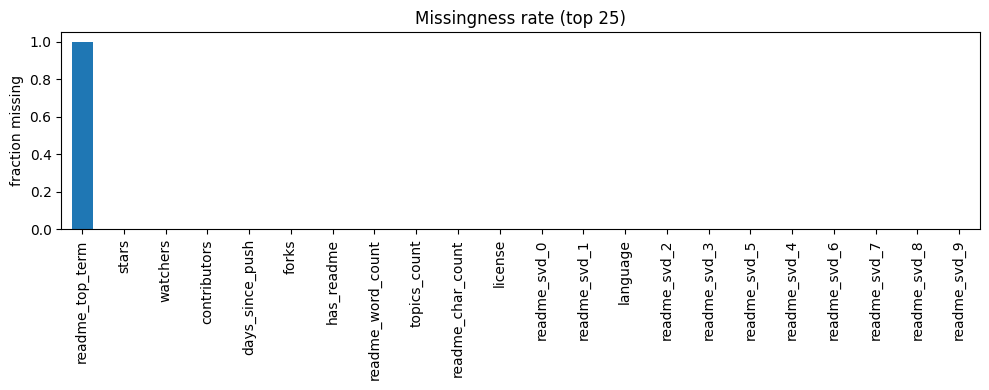

No standard id/url/name keys found for duplicate check.
Leakage/label-ish columns: []
Constant columns: ['contributors', 'has_readme', 'readme_word_count', 'readme_char_count', 'readme_svd_0', 'readme_svd_1', 'readme_svd_2', 'readme_svd_3', 'readme_svd_4', 'readme_svd_5', 'readme_svd_6', 'readme_svd_7', 'readme_svd_8', 'readme_svd_9', 'readme_top_term']


,missing_fraction
readme_top_term,1.0
stars,0.0
watchers,0.0
contributors,0.0
days_since_push,0.0
forks,0.0
has_readme,0.0
readme_word_count,0.0
topics_count,0.0
readme_char_count,0.0


,count,mean,std,min,50%,75%,90%,95%,99%,max
stars,1000.0,53736.96700,42899.827292,27607.00,39641.500,58703.75,87649.000,118344.3000,244721.2800,426893.00
forks,1000.0,8614.31100,10604.446858,410.00,5581.500,9632.00,17162.900,28960.7500,54476.1200,90466.00
watchers,1000.0,971.78500,1146.937776,51.00,595.000,1229.50,2087.700,2946.2500,6251.4500,9879.00
contributors,1000.0,0.00000,0.000000,0.00,0.000,0.00,0.000,0.0000,0.0000,0.00
days_since_push,1000.0,277.07003,216.026858,170.65,174.535,273.48,562.062,649.4975,1128.0737,2269.56
has_readme,1000.0,0.00000,0.000000,0.00,0.000,0.00,0.000,0.0000,0.0000,0.00
readme_word_count,1000.0,0.00000,0.000000,0.00,0.000,0.00,0.000,0.0000,0.0000,0.00
readme_char_count,1000.0,0.00000,0.000000,0.00,0.000,0.00,0.000,0.0000,0.0000,0.00
topics_count,1000.0,6.27200,3.710766,0.00,7.000,10.00,10.000,10.0000,10.0000,10.00
readme_svd_0,1000.0,0.00000,0.000000,0.00,0.000,0.00,0.000,0.0000,0.0000,0.00


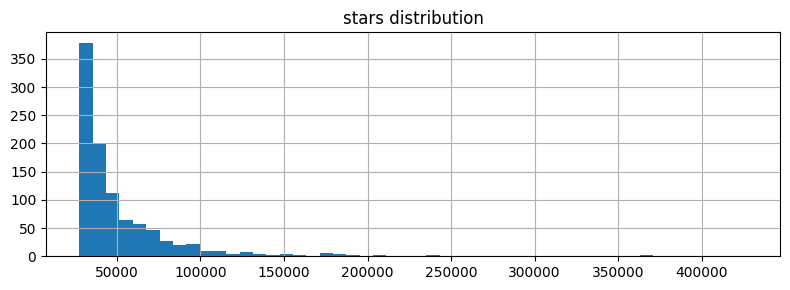

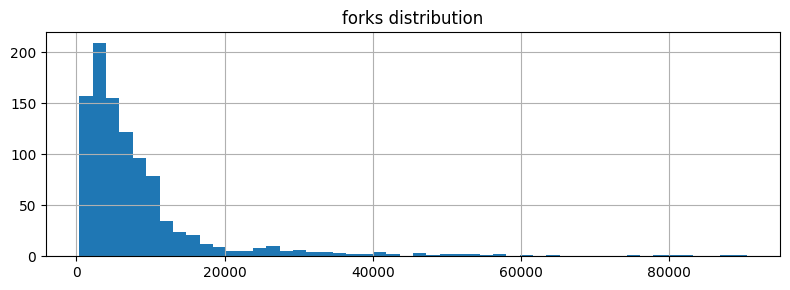

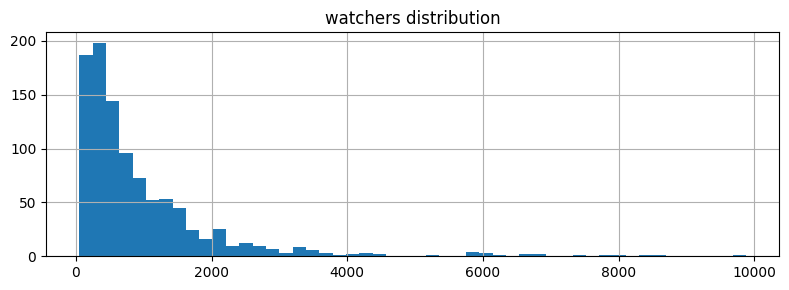

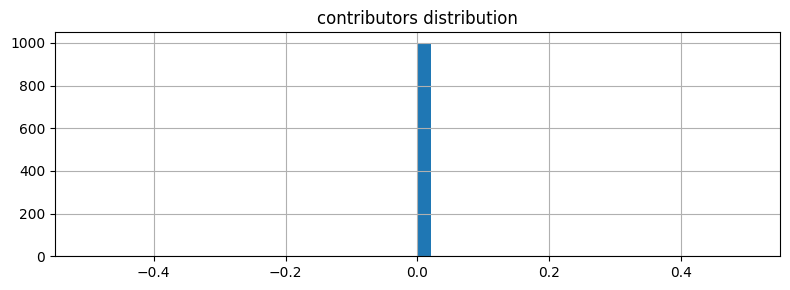

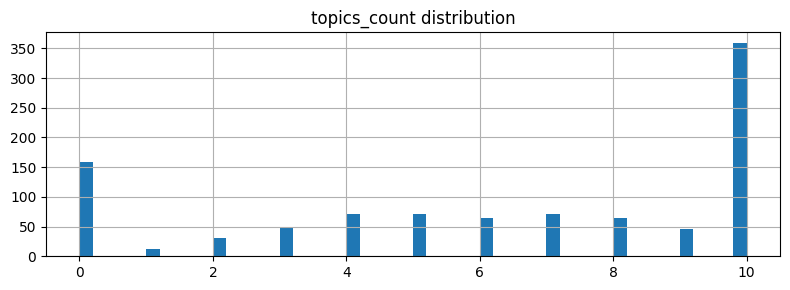

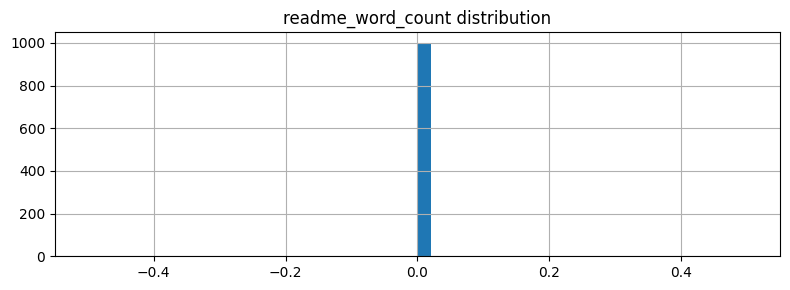

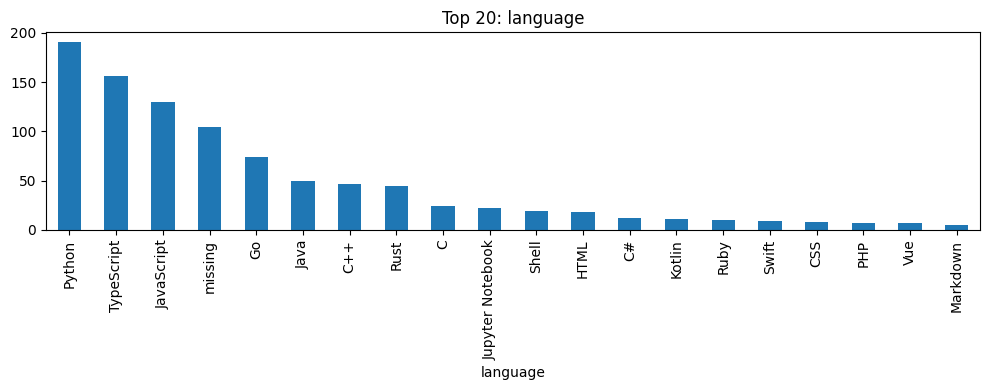

,count
language,
Python,191
TypeScript,156
JavaScript,130
missing,104
Go,74
Java,50
C++,47
Rust,45
C,24


C:\Users\irina\AppData\Local\Temp\ipykernel_15884\985247989.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


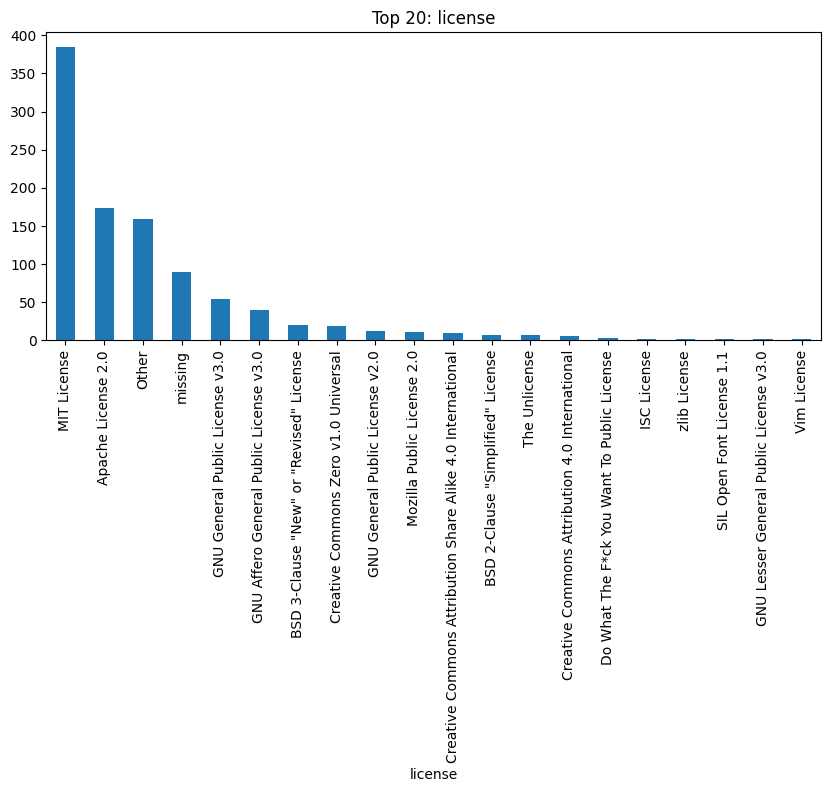

,count
license,
MIT License,385
Apache License 2.0,173
Other,159
missing,89
GNU General Public License v3.0,54
GNU Affero General Public License v3.0,40
"BSD 3-Clause ""New"" or ""Revised"" License",20
Creative Commons Zero v1.0 Universal,19
GNU General Public License v2.0,12


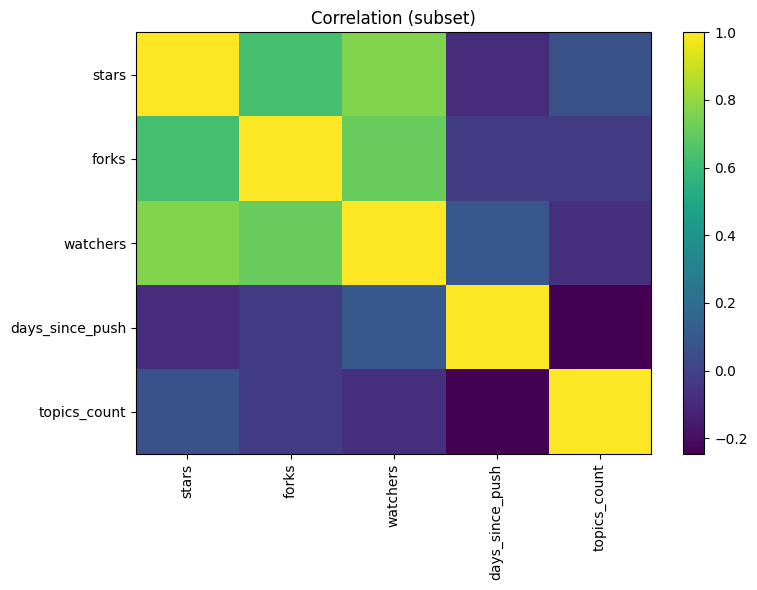

In [21]:
if df is None or len(df) == 0:
    print("No df loaded, cannot run EDA.")
else:
    schema = eda_overview(df)
    eda_missingness(df)
    eda_duplicates(df)
    eda_leakage_checks(df)

    eda_numeric(df)
    eda_categorical(df)
    eda_correlation(df)

    eda_text(df)
    eda_topic_like(df)

## Next Steps

- [ ] Try LightGBM ranker with `lambdarank` objective
- [ ] Add more features (readme analysis, contributor count, issue stats)
- [ ] Test with more queries and build a proper evaluation set
- [ ] Compare pretrained cross-encoder vs custom model
- [ ] Export trained model for production serving